Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


Carregamento e Limpeza

In [2]:
nome_arquivo = '../dataset_classificacao_vogal_A_normal.csv'
df = pd.read_csv(nome_arquivo)

print(f"📊 Dataset Original: {df.shape[0]} linhas.")

# Limpeza padrão
colunas_inuteis = ['Nome_Arquivo', 'Patologia_Original', 'ID_Gravacao', 'ID_Paciente']
df_limpo = df.drop(columns=colunas_inuteis, errors='ignore')
df_limpo = df_limpo.dropna()

if 'Idade' in df_limpo.columns:
    df_limpo['Idade'] = df_limpo['Idade'].round().astype(int)

le = LabelEncoder()
if 'Sexo' in df_limpo.columns:
    df_limpo['Sexo'] = le.fit_transform(df_limpo['Sexo'])

print("✅ Dados limpos.")

📊 Dataset Original: 1464 linhas.
✅ Dados limpos.


Divisão Treino e Este

In [3]:
X = df_limpo.drop('Grupo_Alvo', axis=1)
y = df_limpo['Grupo_Alvo']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"🔹 Treino: {X_train.shape[0]}")
print(f"🔸 Teste:  {X_test.shape[0]}")

🔹 Treino: 1170
🔸 Teste:  293


Scaler

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)

print("✅ Normalização concluída.")

✅ Normalização concluída.


Balanceamento UnderSampling

DISTRIBUIÇÃO ANTES:
Counter({1: 567, 0: 549, 2: 54})

 Aplicando RandomUnderSampler...
NOVA DISTRIBUIÇÃO:
Counter({0: 54, 1: 54, 2: 54})


C:\Users\Administrador\AppData\Local\Temp\ipykernel_15592\3817038647.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')
C:\Users\Administrador\AppData\Local\Temp\ipykernel_15592\3817038647.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_bal, palette='viridis')


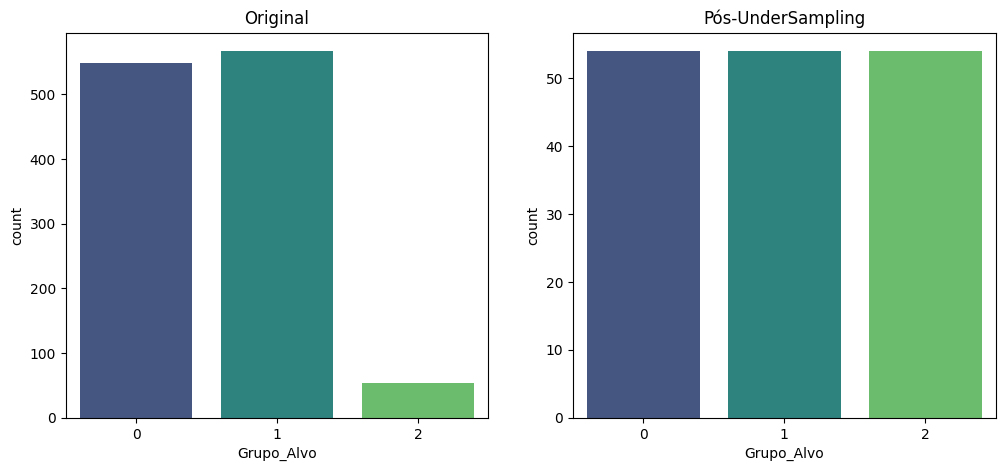

In [5]:
print("DISTRIBUIÇÃO ANTES:")
print(Counter(y_train))

print("\n Aplicando RandomUnderSampler...")

# Sem try/except. Se der erro, vai estourar na tela.
rus = RandomUnderSampler(random_state=42)
X_train_bal, y_train_bal = rus.fit_resample(X_train_final, y_train)

print("NOVA DISTRIBUIÇÃO:")
print(Counter(y_train_bal))

# Visualização
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train, palette='viridis')
plt.title("Original")
plt.subplot(1, 2, 2)
sns.countplot(x=y_train_bal, palette='viridis')
plt.title("Pós-UnderSampling")
plt.show()

Salvamento

In [6]:
X_train_bal.to_csv('X_train_under.csv', index=False)
y_train_bal.to_csv('y_train_under.csv', index=False)
X_test_final.to_csv('X_test_scaled.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("💾 Arquivos salvos nesta pasta com sucesso!")

💾 Arquivos salvos nesta pasta com sucesso!
